<a href="https://colab.research.google.com/github/ompatil2004/Task5_Slashmark/blob/main/Task5_SlashMark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [Colab Cell 1] Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

# [Colab Cell 2] Load the dataset
# Make sure to upload your CSV file to the Colab environment first
df = pd.read_csv('BlackFridaySales.csv')

# Display basic info
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (550068, 12)


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [2]:
# [Colab Cell 3] Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

# Fill missing values
# Product categories are categorical, so we can fill missing ones with a distinct placeholder (like 0 or -1)
df['Product_Category_2'].fillna(0, inplace=True)
df['Product_Category_3'].fillna(0, inplace=True)

# Verify missing values are handled
print("\nMissing values after imputation:\n", df.isnull().sum())

Missing values in each column:
 User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

Missing values after imputation:
 User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64


In [3]:
# [Colab Cell 4] Feature Engineering
# Drop identifiers that don't provide direct predictive power for a basic model
# (Though advanced techniques like Target Encoding could use them, dropping is safer for an intermediate baseline)
if 'User_ID' in df.columns and 'Product_ID' in df.columns:
    df = df.drop(['User_ID', 'Product_ID'], axis=1)

# Initialize LabelEncoder
le = LabelEncoder()

# List of categorical columns to encode
categorical_cols = ['Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status']

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# Display the transformed dataset
display(df.head())

,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,0,0,2,0,2,0,3,0.0,0.0,8370
1,0,0,2,0,2,0,1,6.0,14.0,15200
2,0,0,2,0,2,0,12,0.0,0.0,1422
3,0,0,2,0,2,0,12,14.0,0.0,1057
4,1,6,8,2,4,0,8,0.0,0.0,7969


In [4]:
# [Colab Cell 5] Prepare data for modeling
# Assume 'Purchase' is our target variable to forecast
X = df.drop('Purchase', axis=1)
y = df['Purchase']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Optional for XGBoost, but good practice for continuous variables)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Training Data Shape: (440054, 9)
Testing Data Shape: (110014, 9)


In [5]:
# [Colab Cell 6] Initialize and train the XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1 # Uses all available CPU cores
)

print("Training the model... (this may take a minute)")
xgb_model.fit(X_train_scaled, y_train)
print("Model training complete!")

Training the model... (this may take a minute)
Model training complete!


Root Mean Squared Error (RMSE): 2884.59
R-squared Score (R2): 0.6688


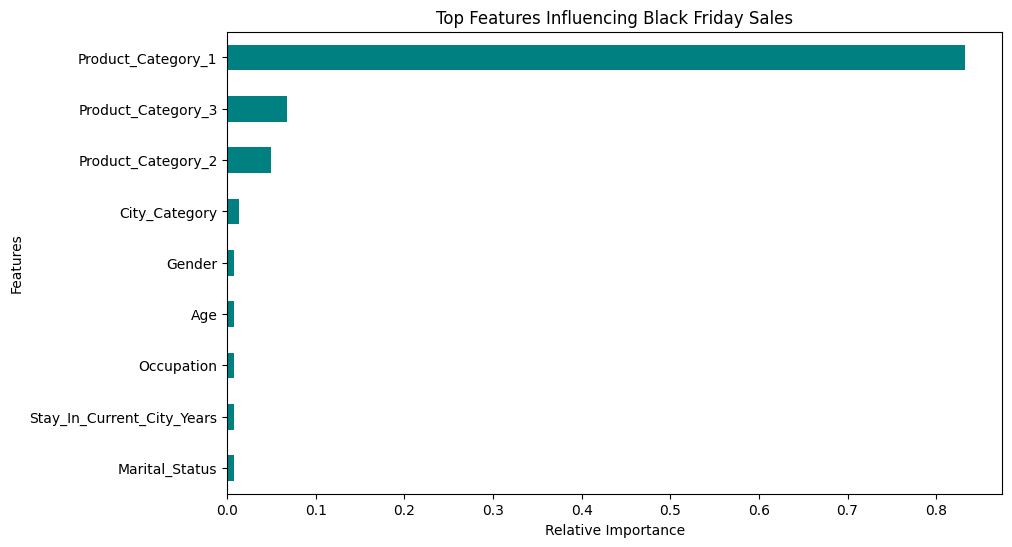

In [6]:
# [Colab Cell 7] Predict and Evaluate
y_pred = xgb_model.predict(X_test_scaled)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

# Plot Feature Importance
plt.figure(figsize=(10, 6))
feature_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top Features Influencing Black Friday Sales')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.show()